# EV and PV detection from Victorville hourly AMI

This notebook screens **AMI profiles** for EV-like charging and recorded PV presence. It compares four classifiers with a majority-class baseline, holds out 20% of IDs, and recommends a model **separately for EV and PV** using training cross-validation.

**Current experiment: EV heuristics plus DER-backed PV labels, still UNVALIDATED.** When `CKT_245_16925_DER.csv` is present, PV positives come from qualifying permission-to-operate (PTO) records, not load-shape rules. As authorized, AMI IDs with **no DER record** are provisional negatives; absence from the registry does not establish absence of PV. Pending/cancelled-only PV records, storage-only records, and first PV installations during the feature window remain unknown. EV labels still come from load-shape rules; their scores measure rule agreement, not verified EV ownership. A profile can have both EV and PV.

**Join granularity matters:** `customer_id` in the code means the AMI column ID matched to DER `STRUCT_NUM`. Multiple service-point/meter IDs can share a structure ID. The PV target is therefore **at least one qualifying PV installation at that structure**, not a verified label for a unique individual customer. DER fields are used only for labels and audit reports, never as classifier features.

The supplied `AMI_COLUMNAR.csv` contains 8,760 hourly rows and 688 AMI columns for 2025. Counts are checked again at runtime. EV features use the full year. PV features are restricted to a conservative registry-aligned window, and positive PV labels require PTO by the start of that window. This analysis does not locate individual charging sessions.

**Run all cells in order.** Supporting functions are in [`notebooks/ev_pv_detection.py`](notebooks/ev_pv_detection.py). The previous notebook is preserved at `runtime/ev_pv_detection/Electric_Vehicle_Detection.original.ipynb`. This version replaces the incomplete Python 2 training/submission sections and retains load-profile, moving-average, and histogram exploration.

## 1. Configuration and reproducibility

Dependencies are listed in `notebooks/requirements-ev-pv.txt`; if needed, install them in your notebook kernel with `%pip install -r notebooks/requirements-ev-pv.txt`, then restart the kernel. Nothing is installed automatically by this notebook. On Windows, launch Jupyter from the activated `powerflow311` Conda environment and select its kernel so the native numerical libraries resolve correctly.

Readings are kept in **source meter units**. Confirm whether the file contains hourly energy, average power, net import, or gross/import-only consumption before interpreting physical magnitudes. The file provides no unit metadata; screening thresholds therefore use ratios and within-customer variability. Naive timestamps are assumed to represent the local meter clock. Set `TIMESTAMP_TIMEZONE='UTC'` if they actually represent UTC; aware timestamps are converted to `America/Los_Angeles`.

In [59]:
from pathlib import Path
import sys
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
)

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'AMI_COLUMNAR.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Run from the project folder containing AMI_COLUMNAR.csv.')
sys.path.insert(0, str(ROOT / 'notebooks'))
from ev_pv_detection import (
    load_readings, extract_customer_features, make_heuristic_labels,
    read_confirmed_labels, registry_pv_labels, benchmark_target,
)

DATA_PATH = ROOT / 'AMI_COLUMNAR.csv'
LABELS_PATH = None  # Later: ROOT / 'customer_labels.csv'; 0/1 labels, blank = unknown.
DER_PATH = ROOT / 'CKT_245_16925_DER.csv'
if not DER_PATH.exists():
    DER_PATH = None  # If absent, the original clearly marked PV heuristic is used.
NO_DER_RECORD_AS_NEGATIVE = True  # Explicit user-authorized provisional assumption.
DER_ASOF_DATE = None  # Optional known registry as-of date; otherwise use latest EDW_MODIFIED_DATE.
TIMESTAMP_TIMEZONE = None  # Naive local meter clock; verify with the data provider.
MIN_COVERAGE = 0.90
TEST_SIZE = 0.20
RANDOM_SEED = 42
CV_FOLDS = 5
LABEL_SOURCE = ('confirmed_user_supplied' if LABELS_PATH is not None else
                'der_registry_provisional' if DER_PATH is not None else 'heuristic_unvalidated')
LABEL_SOURCES = {'EV': 'heuristic_unvalidated', 'PV': 'heuristic_unvalidated'}
if LABELS_PATH is not None:
    LABEL_SOURCES = dict.fromkeys(['EV', 'PV'], 'confirmed_user_supplied')
elif DER_PATH is not None:
    LABEL_SOURCES['PV'] = ('der_registry_with_provisional_negatives' if NO_DER_RECORD_AS_NEGATIVE
                           else 'der_registry_positive_only')
RESULTS_DIR = ROOT / 'runtime' / 'ev_pv_detection' / LABEL_SOURCE
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': .18, 'font.size': 10})
MODE_NOTES = {target: ('Held-out user-supplied labels' if source == 'confirmed_user_supplied' else
                       'UNVALIDATED - PV registry evidence; negative labels provisional' if source.startswith('der_registry') else
                       'UNVALIDATED - agreement with heuristic rules')
              for target, source in LABEL_SOURCES.items()}
MODE_NOTE = ('UNVALIDATED: EV rule labels / PV DER evidence and provisional negatives'
             if LABEL_SOURCE == 'der_registry_provisional' else MODE_NOTES['EV'])

def save_figure(fig, name):
    fig.savefig(RESULTS_DIR / f'{name}.png', dpi=170, bbox_inches='tight')
    fig.savefig(RESULTS_DIR / f'{name}.svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)

versions = {'python': platform.python_version(), 'numpy': np.__version__,
            'pandas': pd.__version__, 'scikit_learn': sklearn.__version__}
display(pd.Series(versions, name='version').to_frame())
display(Markdown(f'**Evaluation status: {MODE_NOTE}.**'))

,version
python,3.11.15
numpy,2.2.6
pandas,2.3.3
scikit_learn,1.9.0


**Evaluation status: UNVALIDATED: EV rule labels / PV DER evidence and provisional negatives.**

## 2. Load and audit the data

The first column is time; all remaining columns are customer readings. Quotes around customer IDs are removed consistently. Invalid numeric readings become missing, missing hours are made explicit, and duplicate timestamps/IDs raise an error. Customers below 90% coverage, empty/constant profiles, and exact duplicate profiles are excluded and reported. We do **not** fill long outages with invented readings. Features use observed data; missing feature values are imputed from training customers inside each cross-validation fold.

,value
hourly_intervals,8760
source_customers,688
eligible_customers,682
excluded_customers,6
missing_source_reads,37944
start,2025-01-01 00:00:00
end,2025-12-31 23:00:00
negative_reads,0


,observed_reads,expected_reads,coverage,unique_values,negative_reads,exclusion_reason,eligible
customer_id,,,,,,,
4685559E,6552,8760,0.747945,1928,0,insufficient coverage,False
4855780E,2208,8760,0.252055,102,0,insufficient coverage,False
4875818E,1464,8760,0.167123,1118,0,insufficient coverage,False
4990200E,1464,8760,0.167123,201,0,insufficient coverage,False
4990862E,1464,8760,0.167123,328,0,insufficient coverage,False
5782674,1464,8760,0.167123,165,0,insufficient coverage,False


**No negative readings are present.** Export-based PV evidence is unavailable. This could be import-only/gross metering or an absence of recorded export; it does not establish that PV is absent. Midday dips are only review candidates.

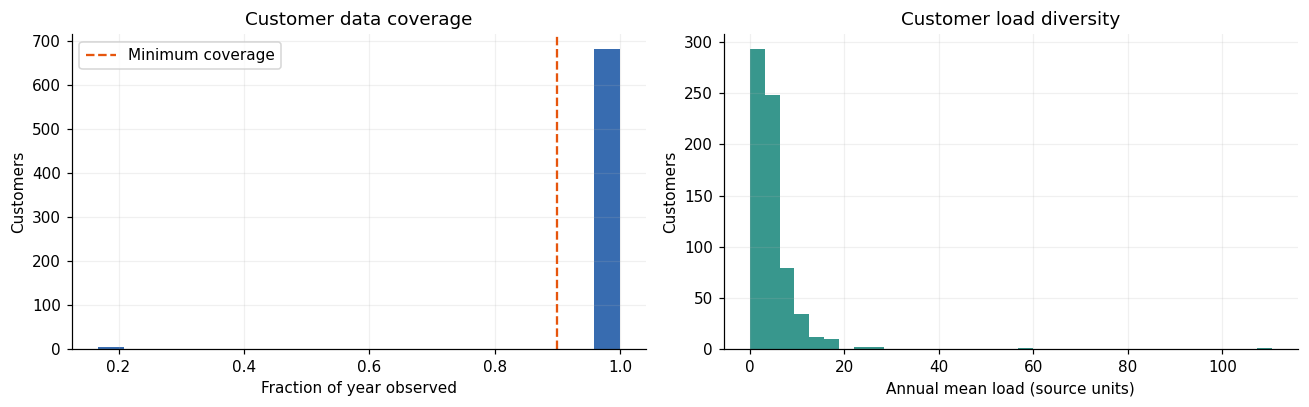

In [60]:
readings, quality = load_readings(DATA_PATH, min_coverage=MIN_COVERAGE,
                                 timestamp_timezone=TIMESTAMP_TIMEZONE)
audit = pd.Series({
    'hourly_intervals': len(readings), 'source_customers': len(quality),
    'eligible_customers': readings.shape[1], 'excluded_customers': int((~quality.eligible).sum()),
    'missing_source_reads': int((quality.expected_reads - quality.observed_reads).sum()),
    'start': str(readings.index.min()), 'end': str(readings.index.max()),
    'negative_reads': int(quality.negative_reads.sum()),
})
display(audit.to_frame('value'))
display(quality.loc[~quality.eligible])
if quality.negative_reads.sum() == 0:
    display(Markdown('**No negative readings are present.** Export-based PV evidence is unavailable. '
                     'This could be import-only/gross metering or an absence of recorded export; '
                     'it does not establish that PV is absent. Midday dips are only review candidates.'))
quality.to_csv(RESULTS_DIR / 'data_quality.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(quality.coverage, bins=20, color='#386cb0')
axes[0].axvline(MIN_COVERAGE, color='#e6550d', linestyle='--', label='Minimum coverage')
axes[0].set(xlabel='Fraction of year observed', ylabel='Customers', title='Customer data coverage')
axes[0].legend()
readings.mean().plot.hist(bins=35, ax=axes[1], color='#38978d')
axes[1].set(xlabel='Annual mean load (source units)', ylabel='Customers', title='Customer load diversity')
fig.tight_layout()
save_figure(fig, '01_data_quality')

## 3. Explore load shape and seasonal confounding

Large loads and sharp ramps alone do not establish EV ownership. In this desert-area dataset, summer air conditioning is a plausible confounder. We include cool-season behavior, overnight behavior, weekday/weekend differences, and load persistence as candidate features. No measured weather is supplied, so seasonal features are only proxies for cooling effects. Likewise, a daytime trough may reflect work schedules, business hours, or other equipment rather than PV.

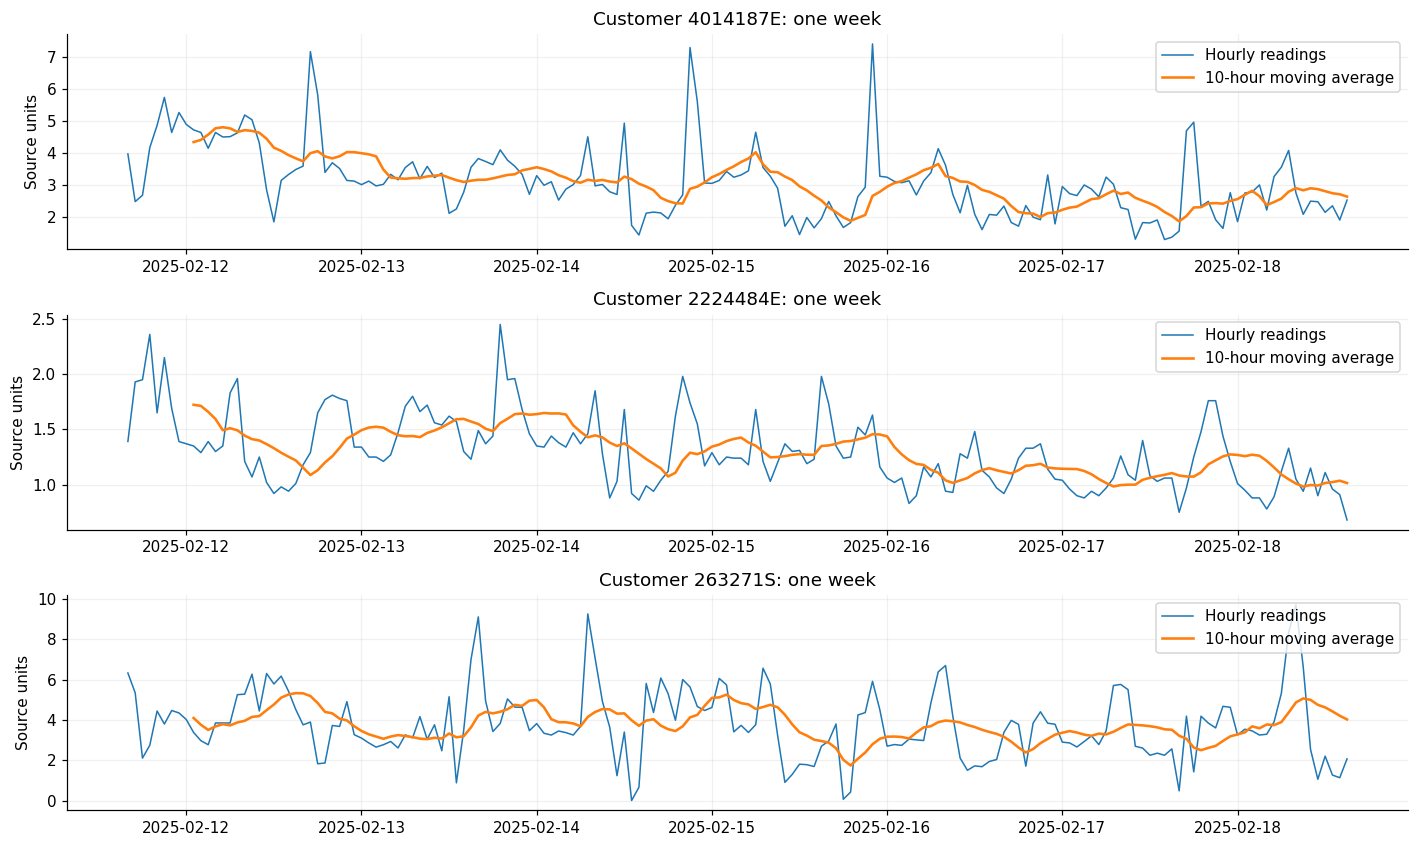

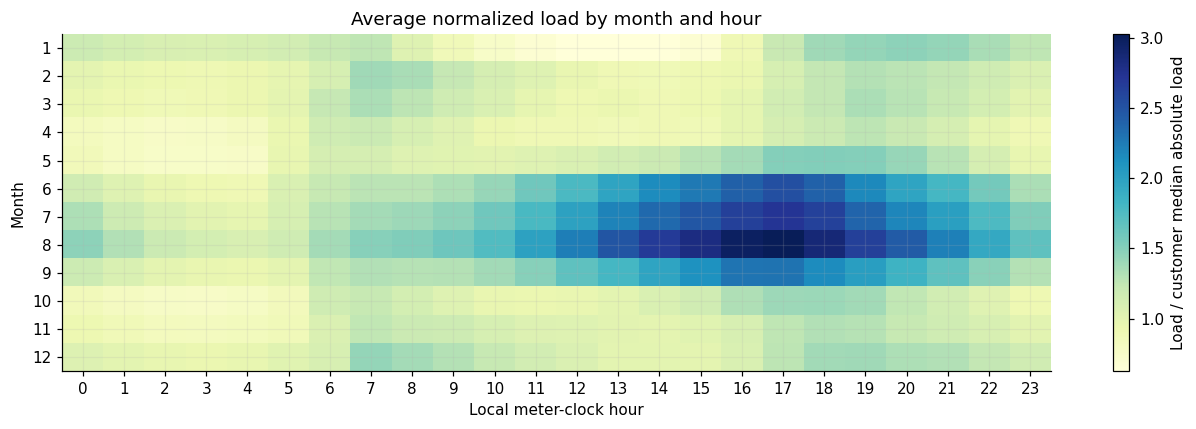

In [61]:
sample_ids = readings.columns.to_series().sample(n=min(3, readings.shape[1]), random_state=RANDOM_SEED).tolist()
fig, axes = plt.subplots(len(sample_ids), 1, figsize=(13, 2.6 * len(sample_ids)), squeeze=False)
for ax, customer in zip(axes.ravel(), sample_ids):
    s = readings[customer].iloc[1000:1168]
    ax.plot(s.index, s, linewidth=1, label='Hourly readings')
    ax.plot(s.index, s.rolling(10, min_periods=10).mean(), linewidth=1.7, label='10-hour moving average')
    ax.set(title=f'Customer {customer}: one week', ylabel='Source units')
    ax.legend(loc='upper right')
fig.tight_layout()
save_figure(fig, '02_sample_profiles')

# Normalize each customer before averaging, so large accounts do not dominate.
normalized = readings.div(readings.abs().median().clip(lower=1e-6), axis=1)
shape = normalized.mean(axis=1).groupby([readings.index.month, readings.index.hour]).mean().unstack()
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(shape, aspect='auto', cmap='YlGnBu')
ax.set(xticks=np.arange(24), xticklabels=shape.columns, yticks=np.arange(len(shape)),
       yticklabels=shape.index, xlabel='Local meter-clock hour', ylabel='Month',
       title='Average normalized load by month and hour')
fig.colorbar(im, ax=ax, label='Load / customer median absolute load')
fig.tight_layout()
save_figure(fig, '03_seasonal_load_shape')

## 4. Build features, join DER records, and distinguish label evidence

One feature row represents one customer's observed year. Features include load quantiles, ramp and moving-average residual histograms, mean hourly/monthly shapes, nighttime/midday behavior, summer-to-cool-season ratios, weekend ratios, and autocorrelation. These summaries use only the customer's own observations; no population statistics are fitted here. See `features.columns` and the supporting module for exact definitions.

### PV labels from interconnection records

The join uses normalized `STRUCT_NUM` values and keeps the `TECH_TYPE` separate from status. **Only PV with `INTERCONNECTION_STATUS == 'PTO ISSUED'` and a valid `PERMTO_OPERATE_DT` on/before the feature-window start qualifies as positive.** An application-complete date, a `CONNECTED` flag, or a battery record alone cannot establish operational PV. `1900-01-01` PTO values are treated as placeholders. Conflicting statuses for the same project are withheld. Multiple inverter/application rows do not create extra training examples or multiply capacity. A structure with both PV and storage remains PV-positive when a qualifying PV project exists.

**Temporal alignment:** the supplied DER records carry a June 20, 2025 update timestamp. By default, use readings only through the end of the previous day (June 19) for PV, and require PTO by January 1. First PV installations during this window are excluded because their annual/period label changes. `EDW_MODIFIED_DATE` is an update timestamp, not proof that the registry is complete; override `DER_ASOF_DATE` if a known as-of date is available. Missing records remain provisional negatives even with this cutoff. EV continues to use all 8,760 readings.

Records that are only pending, cancelled, storage, another technology, missing valid PTO, or first installed during/after the window remain **unknown**, unless another project establishes earlier PV presence at that structure. Only IDs with **no DER record at all** receive the provisional negative label. Independent customer labels supplied via `LABELS_PATH` override this workflow.

### Fixed exploratory load-shape rules

The EV rule remains the training target without confirmed EV labels. The PV rule is retained for descriptive comparison and as a fallback only when no DER file is available. Neither rule is tuned to test accuracy.

| Target | Positive screening rule | Main limitation |
|---|---|---|
| EV | Repeated 2–8 hour elevated blocks starting 18:00–06:00, with sharp entry/exit and a relatively steady plateau; qualifying starts on at least 4% of well-observed days and 2% of cool-season days | HVAC, pumps, and other timed loads can match; low-power/daytime charging may be missed |
| PV | Midday export on at least 5% of observed midday hours **or** a recurring midday trough: ratio below 0.55 on at least 35% of valid days and median ratio below 0.80, with at least 60 valid days | Import-only data and occupancy schedules make this weak evidence; self-consumed PV may be missed |

EV elevation is relative to the preceding 24-hour lower quartile: `max(1.5 * annual IQR, 0.75 * median absolute load)`. Entry/exit ramps must exceed half that elevation and plateau standard deviation must be below 40% of it. Cool months are October–April. PV midday is 10:00–15:00, compared with the **smaller** of the 06:00–09:00 and 17:00–20:00 daily means. Exact rule diagnostics are separate from model inputs; correlated load features still make this a rule-reproduction experiment.

When confirmed labels become available, set `LABELS_PATH` above and rerun all cells. Required CSV columns: `customer_id,has_ev,has_pv`; use `1` for confirmed present, `0` for confirmed absent, and blank for unknown. Unknown labels are excluded separately for each task, never filled with heuristics. Prefer labels valid throughout the observation window and from independent records. No synthetic customer data or invented ground truth is used.

**PV feature window:** 2025-01-01 00:00:00 through 2025-06-19 23:00:00 (4,080 hourly reads). The registry update date is a conservative cutoff assumption.

,value
source_records,1124
source_structures,422
matched_records,1117
unmatched_records,7
missing_structure_records,5
matched_structures,420
structures_with_multiple_service_points,206
project_status_conflict_rows,0
feature_start,2025-01-01 00:00:00
feature_end,2025-06-19 23:00:00


,technology,status,records
0,BATTERY,CANCELLED,11
1,BATTERY,PENDING,12
2,BATTERY,PTO ISSUED,108
3,PHOTOVOLTAIC,CANCELLED,139
4,PHOTOVOLTAIC,PENDING,23
5,PHOTOVOLTAIC,PTO ISSUED,826
6,WIND,CANCELLED,1
7,WIND,PTO ISSUED,4


,eligible_AMI_profiles
label_basis,
pv_pto_before_feature_window,401
no_der_record_provisional_negative,262
first_pv_pto_during_window_unknown,9
pv_pending_cancelled_or_unverified_unknown,8
other_der_without_verified_pv_unknown,2


**PV shape-rule versus DER-label overlap** (descriptive, not a held-out evaluation):

DER_PV_label,0,1
PV_shape_rule,,
0,259,296
1,3,105


Feature matrix: 682 customers x 93 features


,mean_load,std_load,load_p05,load_p25,load_p50,load_p75,load_p95,load_p99,coefficient_of_variation,peak_to_median,...,residual_hist_6,residual_hist_7,ramp_hist_0,ramp_hist_1,ramp_hist_2,ramp_hist_3,ramp_hist_4,ramp_hist_5,ramp_hist_6,ramp_hist_7
customer_id,,,,,,,,,,,,,,,,,,,,,
1544655E,1.220,1.363,0.000,0.324,0.841,1.608,3.643,7.342,1.621,8.730,...,0.075,0.034,0.029,0.071,0.104,0.303,0.291,0.093,0.074,0.037
1553180E,8.463,5.589,3.198,4.609,6.663,10.239,21.156,26.897,0.839,4.037,...,0.095,0.041,0.029,0.090,0.133,0.270,0.230,0.115,0.100,0.034
1591551E,1.828,1.017,0.780,1.050,1.540,2.270,3.860,5.034,0.660,3.269,...,0.093,0.050,0.034,0.083,0.085,0.316,0.290,0.075,0.070,0.047
1591565E,3.304,2.122,1.040,1.890,2.810,4.010,7.980,11.034,0.755,3.927,...,0.093,0.030,0.029,0.090,0.108,0.282,0.271,0.086,0.107,0.027
1591638E,1.178,1.233,0.160,0.350,0.730,1.450,3.850,5.780,1.690,7.918,...,0.079,0.054,0.033,0.070,0.077,0.338,0.311,0.071,0.062,0.038


,has_ev,has_pv
0,410,262
1,272,401
<NA>,0,19


,night_event_days,cool_event_days,night_event_fraction,cool_event_fraction,valid_pv_days,midday_valley_fraction,median_midday_shoulder_ratio,midday_export_fraction,label_source
customer_id,,,,,,,,,
1544655E,11,7,0.030137,0.033019,363,0.272727,1.837500,0.0,heuristic_unvalidated
1553180E,0,0,0.000000,0.000000,365,0.052055,1.514929,0.0,heuristic_unvalidated
1591551E,37,26,0.101370,0.122642,365,0.052055,0.990389,0.0,heuristic_unvalidated
1591565E,7,5,0.019178,0.023585,365,0.095890,0.895652,0.0,heuristic_unvalidated
1591638E,59,32,0.161644,0.150943,365,0.046575,2.155039,0.0,heuristic_unvalidated


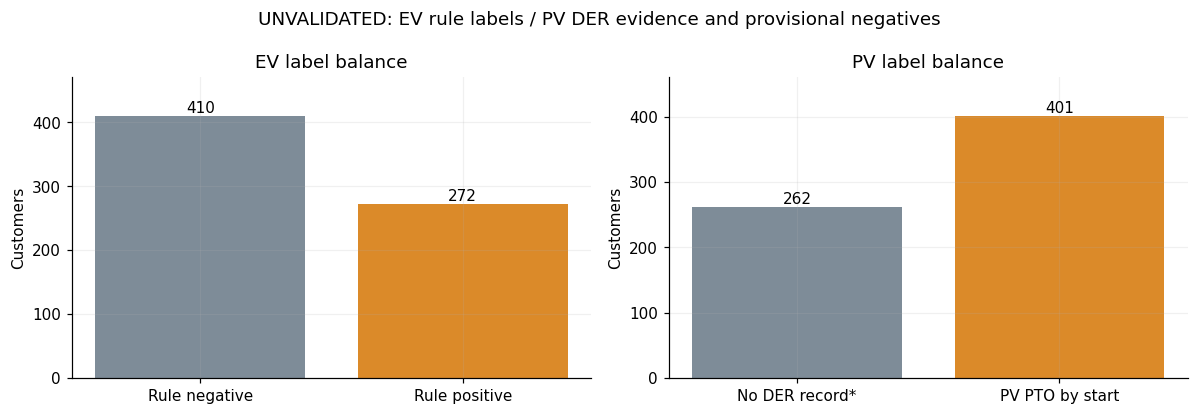

In [62]:
features = extract_customer_features(readings)
heuristic_labels, rule_diagnostics = make_heuristic_labels(readings)
labels = heuristic_labels.copy()
feature_sets = {'EV': features, 'PV': features}
target_readings = {'EV': readings, 'PV': readings}
registry_audit = {}
registry_summary = None
if LABELS_PATH is not None:
    labels, unmatched_ids = read_confirmed_labels(LABELS_PATH, features.index)
    print(f'Label rows without an eligible matching customer: {len(unmatched_ids)}')
    display(pd.Series(unmatched_ids, name='unmatched_customer_id').to_frame())
elif DER_PATH is not None:
    if DER_ASOF_DATE is None:
        modified = pd.to_datetime(pd.read_csv(DER_PATH, usecols=['EDW_MODIFIED_DATE']).EDW_MODIFIED_DATE,
                                  errors='coerce')
        if not modified.notna().any():
            raise ValueError('No registry update dates; set DER_ASOF_DATE explicitly.')
        registry_asof = modified.max().normalize()
    else:
        registry_asof = pd.Timestamp(DER_ASOF_DATE).normalize()
    if readings.index.tz is not None and registry_asof.tzinfo is None:
        registry_asof = registry_asof.tz_localize(readings.index.tz)
    pv_end = min(readings.index.max(), registry_asof - pd.Timedelta(hours=1))
    pv_readings = readings.loc[:pv_end]
    if len(pv_readings) < 30 * 24:
        raise ValueError('Registry and AMI need at least 30 days of overlap for this feature workflow.')
    pv_labels, registry_summary, registry_audit, registry_status_counts = registry_pv_labels(
        DER_PATH, quality.index, pv_readings.index.min(), pv_readings.index.max(),
        no_record_as_negative=NO_DER_RECORD_AS_NEGATIVE, expected_circuit='CKT_245_16925')
    labels['has_pv'] = pv_labels.reindex(features.index)
    target_readings['PV'] = pv_readings
    feature_sets['PV'] = extract_customer_features(pv_readings)
    display(Markdown(f'**PV feature window:** {pv_readings.index.min()} through {pv_readings.index.max()} '
                     f'({len(pv_readings):,} hourly reads). The registry update date is a conservative cutoff assumption.'))
    display(pd.Series(registry_audit).to_frame('value'))
    display(registry_status_counts)
    display(registry_summary.loc[features.index, 'label_basis'].value_counts().rename('eligible_AMI_profiles').to_frame())
    display(Markdown('**PV shape-rule versus DER-label overlap** (descriptive, not a held-out evaluation):'))
    display(pd.crosstab(heuristic_labels.has_pv.rename('PV_shape_rule'), labels.has_pv.rename('DER_PV_label')))
    registry_summary.to_csv(RESULTS_DIR / 'der_structure_label_audit.csv')
    registry_status_counts.to_csv(RESULTS_DIR / 'der_technology_status_counts.csv', index=False)
    (RESULTS_DIR / 'der_join_audit.json').write_text(json.dumps(registry_audit, indent=2), encoding='utf-8')

# A blank template is safe to populate; never overwrite a user's edited copy.
template_path = ROOT / 'runtime' / 'ev_pv_detection' / 'customer_labels_template.csv'
if not template_path.exists():
    pd.DataFrame({'customer_id': quality.index, 'has_ev': pd.NA, 'has_pv': pd.NA}).to_csv(template_path, index=False)

print(f'Feature matrix: {features.shape[0]} customers x {features.shape[1]} features')
display(features.head().round(3))
display(labels.apply(lambda col: col.value_counts(dropna=False)).fillna(0).astype(int))
display(rule_diagnostics.drop(columns=['has_ev', 'has_pv']).head())
features.to_csv(RESULTS_DIR / 'customer_features.csv')
feature_sets['PV'].to_csv(RESULTS_DIR / 'pv_customer_features.csv')
rule_diagnostics.to_csv(RESULTS_DIR / 'heuristic_review_candidates.csv')
labels.assign(ev_label_source=LABEL_SOURCES['EV'], pv_label_source=LABEL_SOURCES['PV']).to_csv(RESULTS_DIR / 'experiment_labels.csv')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, target in zip(axes, ['EV', 'PV']):
    counts = labels[f'has_{target.lower()}'].value_counts().reindex([0, 1], fill_value=0)
    label_names = (['Rule negative', 'Rule positive'] if LABEL_SOURCES[target] == 'heuristic_unvalidated' else
                   ['No DER record*', 'PV PTO by start'] if LABEL_SOURCES[target].startswith('der_registry') else ['Absent', 'Present'])
    bars = ax.bar(label_names,
                  counts, color=['#7e8c98', '#db8a29'])
    ax.bar_label(bars)
    ax.set(title=f'{target} label balance', ylabel='Customers')
    ax.set_ylim(0, max(counts.max() * 1.15, 1))
fig.suptitle(MODE_NOTE)
fig.tight_layout()
save_figure(fig, '04_label_balance')

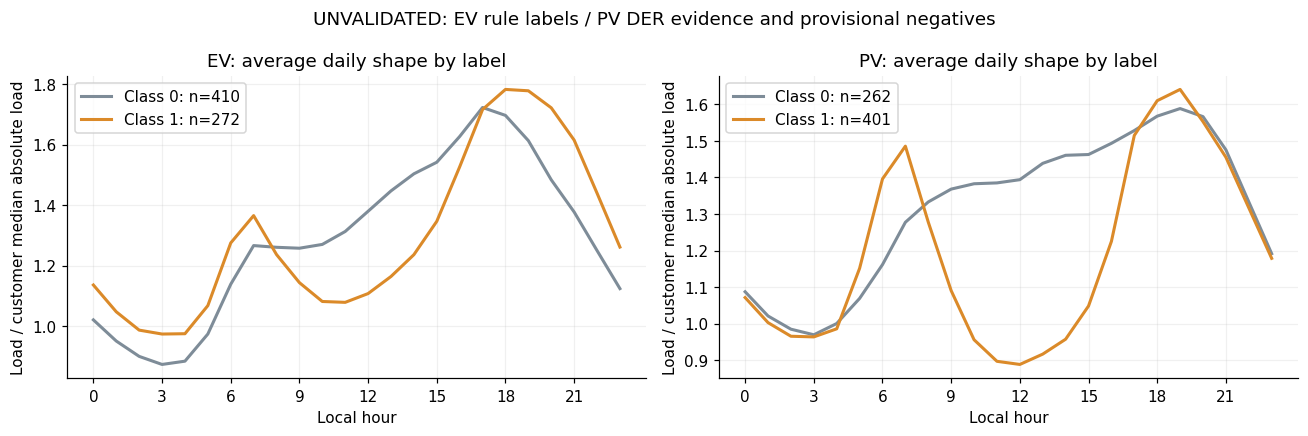

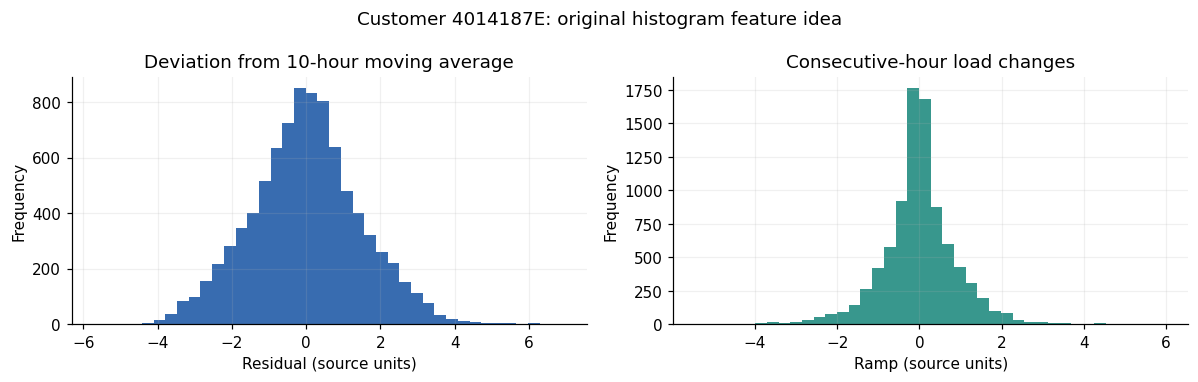

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, target in zip(axes, ['EV', 'PV']):
    window = target_readings[target]
    target_normalized = window.div(window.abs().median().clip(lower=1e-6), axis=1)
    for value, color in [(0, '#7e8c98'), (1, '#db8a29')]:
        ids = labels.index[labels[f'has_{target.lower()}'].eq(value).fillna(False)]
        if len(ids):
            profile = target_normalized[ids].groupby(target_normalized.index.hour).mean().mean(axis=1)
            ax.plot(profile.index, profile, color=color, linewidth=2,
                    label=f'Class {value}: n={len(ids)}')
    ax.set(title=f'{target}: average daily shape by label', xlabel='Local hour',
           ylabel='Load / customer median absolute load', xticks=range(0, 24, 3))
    ax.legend()
fig.suptitle(MODE_NOTE)
fig.tight_layout()
save_figure(fig, '05_label_load_shapes')

sample = readings[sample_ids[0]]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
(sample - sample.rolling(10, min_periods=10).mean()).plot.hist(bins=40, ax=axes[0], color='#386cb0')
sample.diff().plot.hist(bins=40, ax=axes[1], color='#38978d')
axes[0].set(title='Deviation from 10-hour moving average', xlabel='Residual (source units)')
axes[1].set(title='Consecutive-hour load changes', xlabel='Ramp (source units)')
fig.suptitle(f'Customer {sample.name}: original histogram feature idea')
fig.tight_layout()
save_figure(fig, '06_residual_histograms')

## 5. Split by customer and compare classifiers

**80% train / 20% test, stratified separately for each target**, with seed 42. Every AMI ID's readings remain together; they are never split as individual hours. EV uses the full year; DER-based PV uses its shorter registry-aligned window. Unknown labels are excluded from each task separately. EV and PV therefore can have different sample counts, windows, and customer partitions. Their split manifests are exported. Five-fold stratified CV uses only training IDs (automatically reduced when a minority class is small); at least five labeled profiles in each class are required. Small-class results remain uncertain even when computation is possible.

All models see the same folds within each task. Median imputation and scaling are fitted **inside** each training fold. Class weighting is enabled for the four learned classifiers. Fixed, modest model settings avoid an expensive search with only hundreds of examples. Decision thresholds remain at estimator defaults (0.5 for probabilistic classifiers, 0 for SVM decision scores); no test-set threshold tuning occurs.

| Classifier | Reason to compare it |
|---|---|
| Majority baseline | Reveals how misleading raw accuracy can be when positives are scarce |
| Logistic regression | Simple scaled linear model with class weighting |
| RBF SVM | Nonlinear boundary on scaled features for a small customer sample |
| Random forest | Captures nonlinear feature interactions with constrained trees |
| Gradient boosting | Builds sequential small trees for nonlinear tabular patterns, with 32 histogram bins to keep this small-sample comparison fast |

**Selection rule:** highest mean training-CV average precision (AP), with balanced accuracy as a tie-breaker. AP assesses positive ranking and is useful when candidates are uncommon. The winner is frozen **before test results are computed**. The holdout is used once for all model comparison plots; it must not be reused to tune the models. Recommendation strength is provisional when folds disagree or the baseline is not beaten.

In [64]:
results, skipped = {}, {}
for target in ['EV', 'PV']:
    y = labels[f'has_{target.lower()}']
    counts = y.dropna().value_counts()
    if len(counts) != 2 or counts.min() < 5:
        skipped[target] = f'Need at least 5 labeled customers in each class; counts: {counts.to_dict()}.'
        display(Markdown(f'**{target} comparison unavailable:** {skipped[target]} No accuracy is invented.'))
        continue
    print(f'Fitting {target}: {len(y.dropna())} labeled customers...', flush=True)
    results[target] = benchmark_target(feature_sets[target], y, target=target, label_source=LABEL_SOURCES[target],
                                       test_size=TEST_SIZE, seed=RANDOM_SEED, max_folds=CV_FOLDS)

split_rows = []
for target, result in results.items():
    for name, ids in [('train', result.train_ids), ('test', result.test_ids)]:
        values = labels.loc[ids, f'has_{target.lower()}']
        split_rows.append({'target': target, 'split': name, 'customers': len(ids),
                           'negative': int(values.eq(0).sum()), 'positive': int(values.eq(1).sum())})
    assert result.train_ids.intersection(result.test_ids).empty
split_summary = pd.DataFrame(split_rows)
display(split_summary)

Fitting EV: 682 labeled customers...


c:\Users\fgonzales\AppData\Local\anaconda3\envs\powerflow311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Fitting PV: 663 labeled customers...


c:\Users\fgonzales\AppData\Local\anaconda3\envs\powerflow311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,target,split,customers,negative,positive
0,EV,train,545,328,217
1,EV,test,137,82,55
2,PV,train,530,209,321
3,PV,test,133,53,80


## 6. Training cross-validation: choose the recommendations

Error bars are **one standard deviation across validation folds**, not confidence intervals. CV scores were used for selection, so the selected CV score is optimistic; holdout results below provide a separate assessment of agreement. Differences smaller than fold variability do not establish a clear winner.

**EV: selected on training CV — RBF SVM.**

,cv_accuracy,cv_balanced_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc,cv_average_precision,cv_average_precision_std
model,,,,,,,,
Majority baseline,0.602,0.500,0.000,0.000,0.000,0.500,0.398,0.005
Logistic regression,0.817,0.811,0.771,0.783,0.775,0.885,0.820,0.063
RBF SVM,0.813,0.806,0.767,0.774,0.768,0.892,0.861,0.062
Random forest,0.807,0.803,0.756,0.783,0.767,0.896,0.853,0.042
Gradient boosting,0.806,0.797,0.762,0.756,0.757,0.892,0.854,0.039


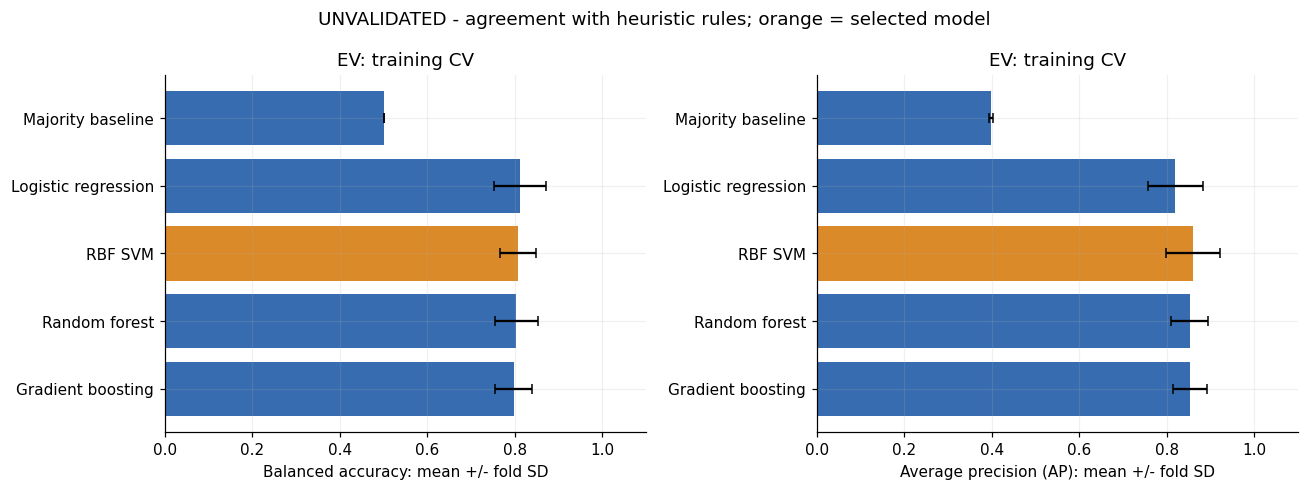

**PV: selected on training CV — Random forest.**

,cv_accuracy,cv_balanced_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc,cv_average_precision,cv_average_precision_std
model,,,,,,,,
Majority baseline,0.606,0.500,0.606,1.000,0.754,0.500,0.606,0.004
Logistic regression,0.921,0.922,0.952,0.916,0.933,0.964,0.962,0.048
RBF SVM,0.925,0.929,0.968,0.906,0.935,0.985,0.991,0.004
Random forest,0.949,0.947,0.960,0.956,0.958,0.991,0.994,0.004
Gradient boosting,0.962,0.961,0.972,0.966,0.969,0.990,0.993,0.010


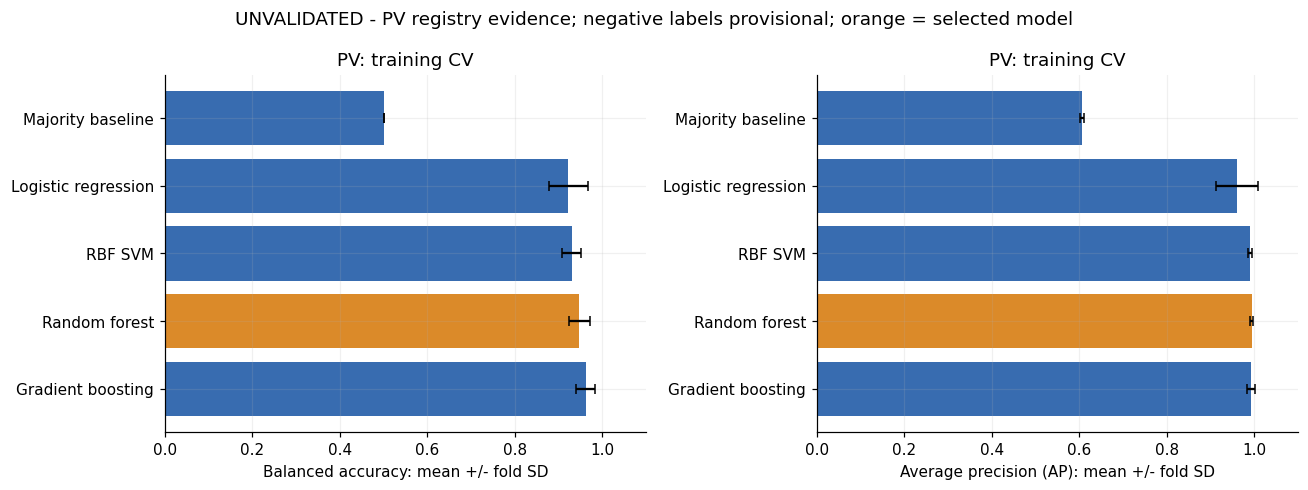

In [65]:
for target, result in results.items():
    display(Markdown(f'**{target}: selected on training CV — {result.selected_name}.**'))
    display(result.cv[['cv_accuracy', 'cv_balanced_accuracy', 'cv_precision', 'cv_recall',
                       'cv_f1', 'cv_roc_auc', 'cv_average_precision', 'cv_average_precision_std']].round(3))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    table = result.cv
    for ax, metric, title in zip(axes, ['balanced_accuracy', 'average_precision'], ['Balanced accuracy', 'Average precision (AP)']):
        colors = ['#db8a29' if m == result.selected_name else '#386cb0' for m in table.index]
        ax.barh(table.index, table[f'cv_{metric}'], xerr=table[f'cv_{metric}_std'], color=colors, capsize=3)
        ax.set(xlim=(0, 1.1), xlabel=f'{title}: mean +/- fold SD', title=f'{target}: training CV')
        ax.invert_yaxis()
    fig.suptitle(f'{MODE_NOTES[target]}; orange = selected model')
    fig.tight_layout()
    save_figure(fig, f'07_{target.lower()}_training_cv')

## 7. Held-out accuracy and class-sensitive metrics

Accuracy is the fraction of correctly matched labels. Balanced accuracy averages recall for both classes; precision measures how many flagged customers match positive labels; recall measures how many positive labels are found; F1 balances precision and recall. ROC AUC and AP assess ranking across thresholds. AP is reported directly, not trapezoidal PR AUC. A no-skill AP is approximately positive prevalence.

The accuracy chart shows **95% Wilson intervals**. These describe finite test-sample uncertainty only; they do not account for false heuristic labels, registry omissions, structure-to-meter ambiguity, model selection, or shared feeder behavior. EV scores measure heuristic agreement. PV scores measure agreement with prior PTO evidence versus the assumed-negative nonmatches; they are not fully verified ownership accuracy.

**EV: held-out evaluation — UNVALIDATED - agreement with heuristic rules.**

,accuracy,accuracy_low,accuracy_high,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,test_customers,test_positives
model,,,,,,,,,,,
Majority baseline,0.599,0.515,0.677,0.500,0.000,0.000,0.000,0.500,0.401,137,55
Logistic regression,0.796,0.720,0.855,0.787,0.745,0.745,0.745,0.887,0.848,137,55
RBF SVM,0.803,0.728,0.861,0.793,0.759,0.745,0.752,0.870,0.830,137,55
Random forest,0.818,0.744,0.873,0.806,0.788,0.745,0.766,0.881,0.835,137,55
Gradient boosting,0.810,0.736,0.867,0.800,0.774,0.745,0.759,0.889,0.836,137,55


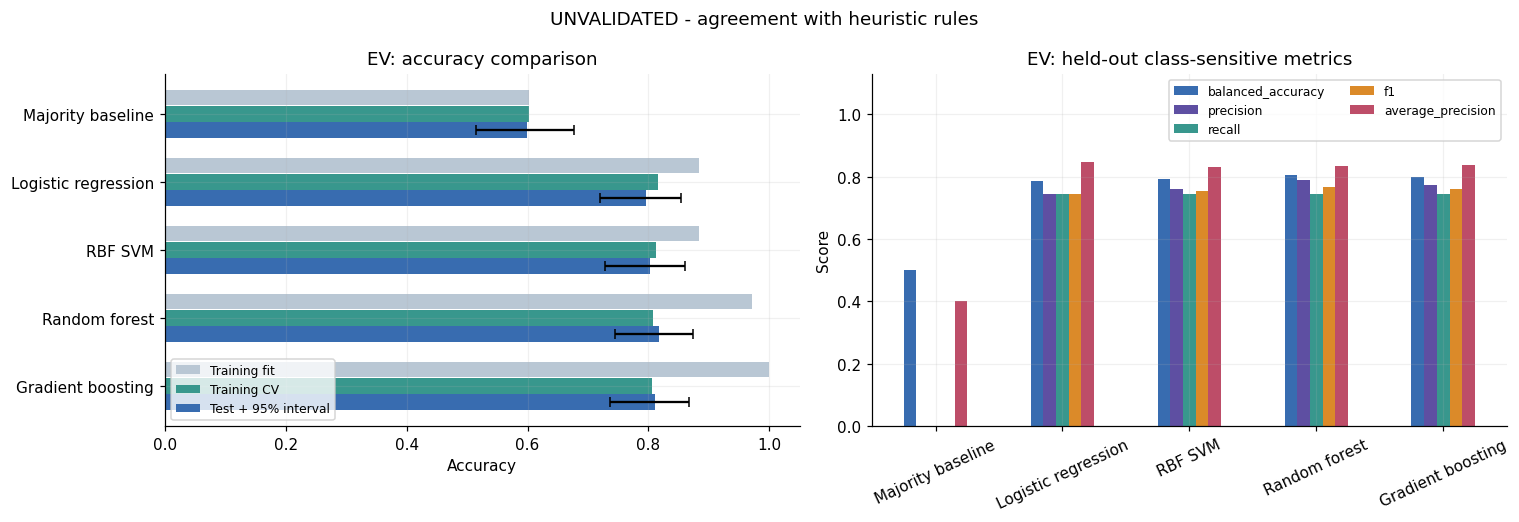

**PV: held-out evaluation — UNVALIDATED - PV registry evidence; negative labels provisional.**

,accuracy,accuracy_low,accuracy_high,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,test_customers,test_positives
model,,,,,,,,,,,
Majority baseline,0.602,0.517,0.681,0.500,0.602,1.000,0.751,0.500,0.602,133,80
Logistic regression,0.932,0.876,0.964,0.937,0.973,0.912,0.942,0.981,0.990,133,80
RBF SVM,0.910,0.849,0.948,0.915,0.959,0.888,0.922,0.980,0.987,133,80
Random forest,0.955,0.905,0.979,0.956,0.974,0.950,0.962,0.990,0.993,133,80
Gradient boosting,0.947,0.895,0.974,0.950,0.974,0.938,0.955,0.989,0.992,133,80


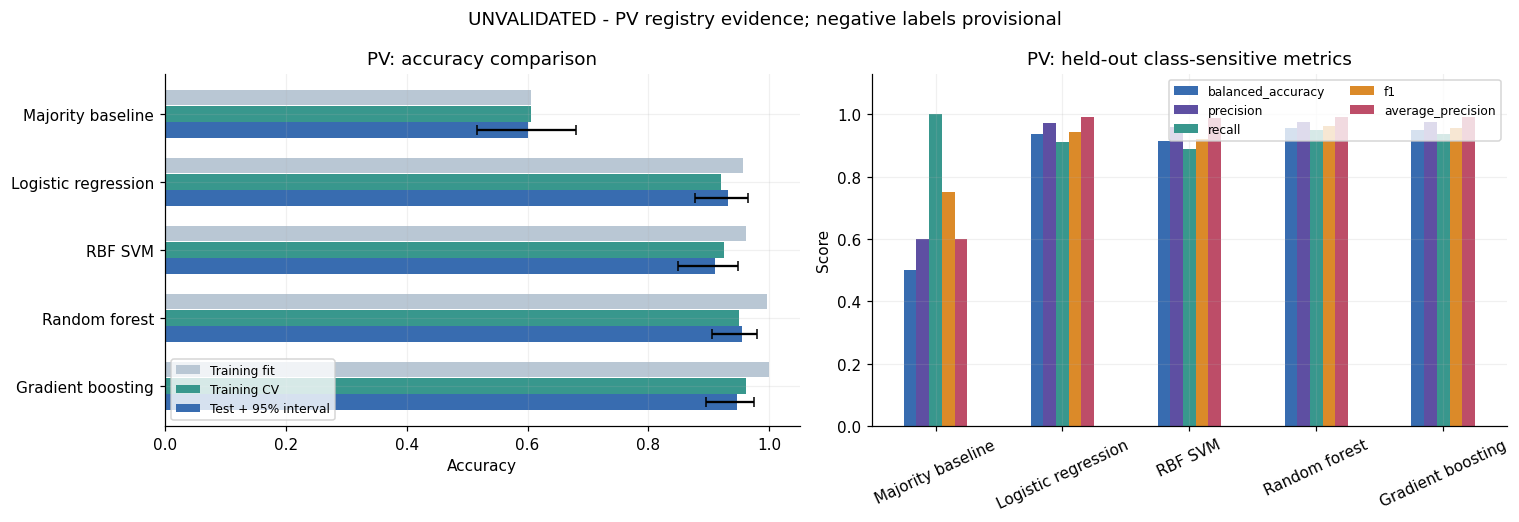

In [66]:
for target, result in results.items():
    table = result.test
    display(Markdown(f'**{target}: held-out evaluation — {MODE_NOTES[target]}.**'))
    display(table[['accuracy', 'accuracy_low', 'accuracy_high', 'balanced_accuracy', 'precision',
                   'recall', 'f1', 'roc_auc', 'average_precision', 'test_customers', 'test_positives']].round(3))
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    positions = np.arange(len(table))
    axes[0].barh(positions - .24, table.train_accuracy, height=.23, label='Training fit', color='#b9c7d4')
    axes[0].barh(positions, result.cv.loc[table.index, 'cv_accuracy'], height=.23, label='Training CV', color='#38978d')
    errors = np.vstack([table.accuracy - table.accuracy_low, table.accuracy_high - table.accuracy])
    axes[0].barh(positions + .24, table.accuracy, height=.23, label='Test + 95% interval',
                 color='#386cb0', xerr=np.maximum(errors, 0), capsize=3)
    axes[0].set(yticks=positions, yticklabels=table.index, xlim=(0, 1.05), xlabel='Accuracy', title=f'{target}: accuracy comparison')
    axes[0].invert_yaxis()
    axes[0].legend(loc='lower left', fontsize=8)
    table[['balanced_accuracy', 'precision', 'recall', 'f1', 'average_precision']].plot.bar(
        ax=axes[1], color=['#386cb0', '#5e4fa2', '#38978d', '#db8a29', '#bd4d68'])
    axes[1].set(ylim=(0, 1.13), ylabel='Score', xlabel='', title=f'{target}: held-out class-sensitive metrics')
    axes[1].tick_params(axis='x', rotation=25)
    axes[1].legend(fontsize=8, ncol=2, loc='upper right')
    fig.suptitle(MODE_NOTES[target])
    fig.tight_layout()
    save_figure(fig, f'08_{target.lower()}_accuracy_metrics')

## 8. ROC, precision–recall, and confusion matrices

The dashed ROC diagonal is chance ranking; the dashed precision line is held-out positive prevalence. Scores from class-weighted models are not calibrated ownership probabilities; SVM uses a decision score. Confusion matrices always use label order `[0, 1]`, with true labels on rows and predictions on columns. The default thresholds were set before evaluating this holdout.

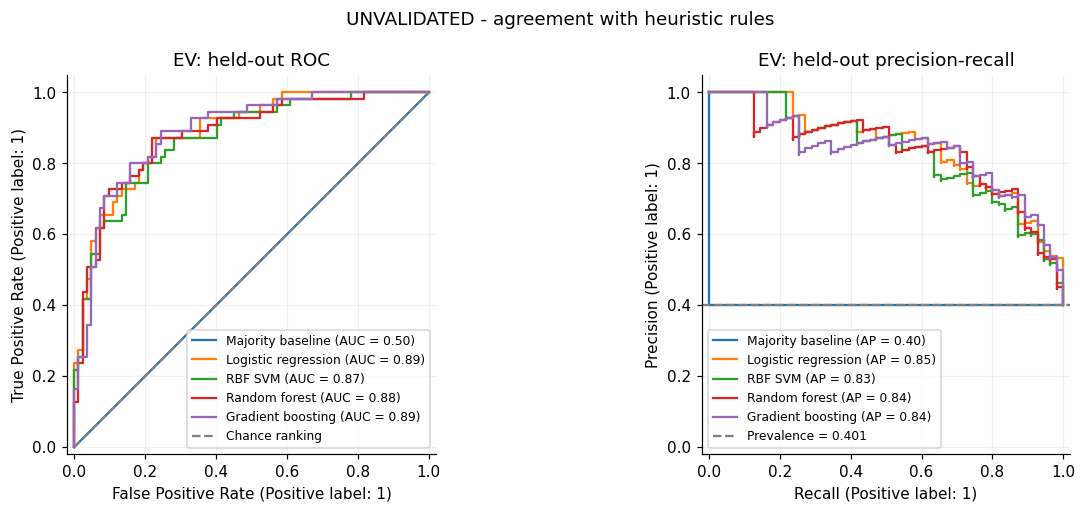

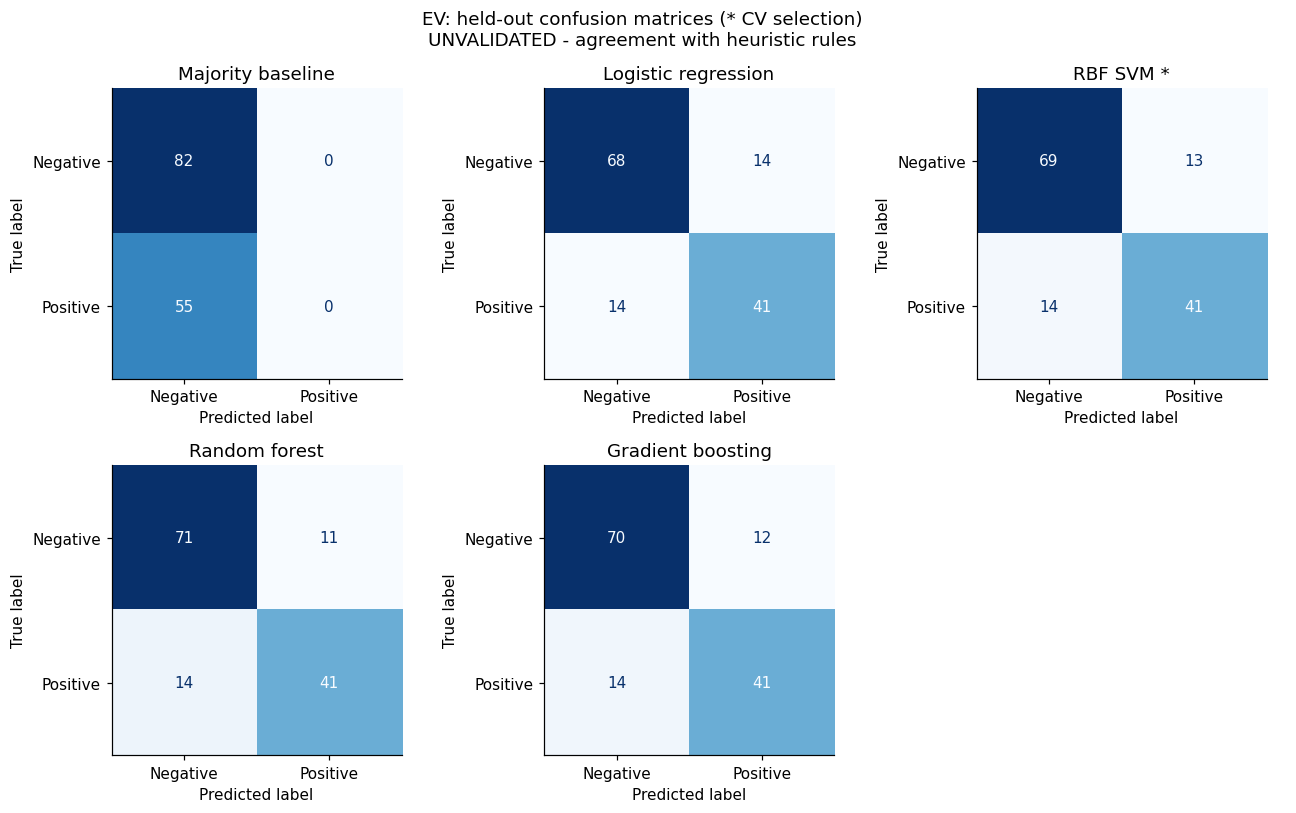

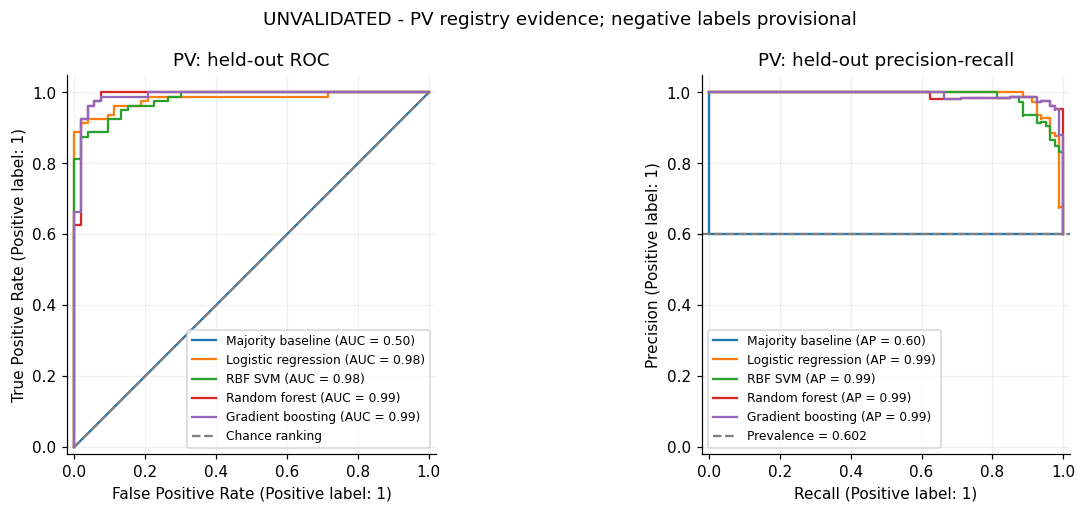

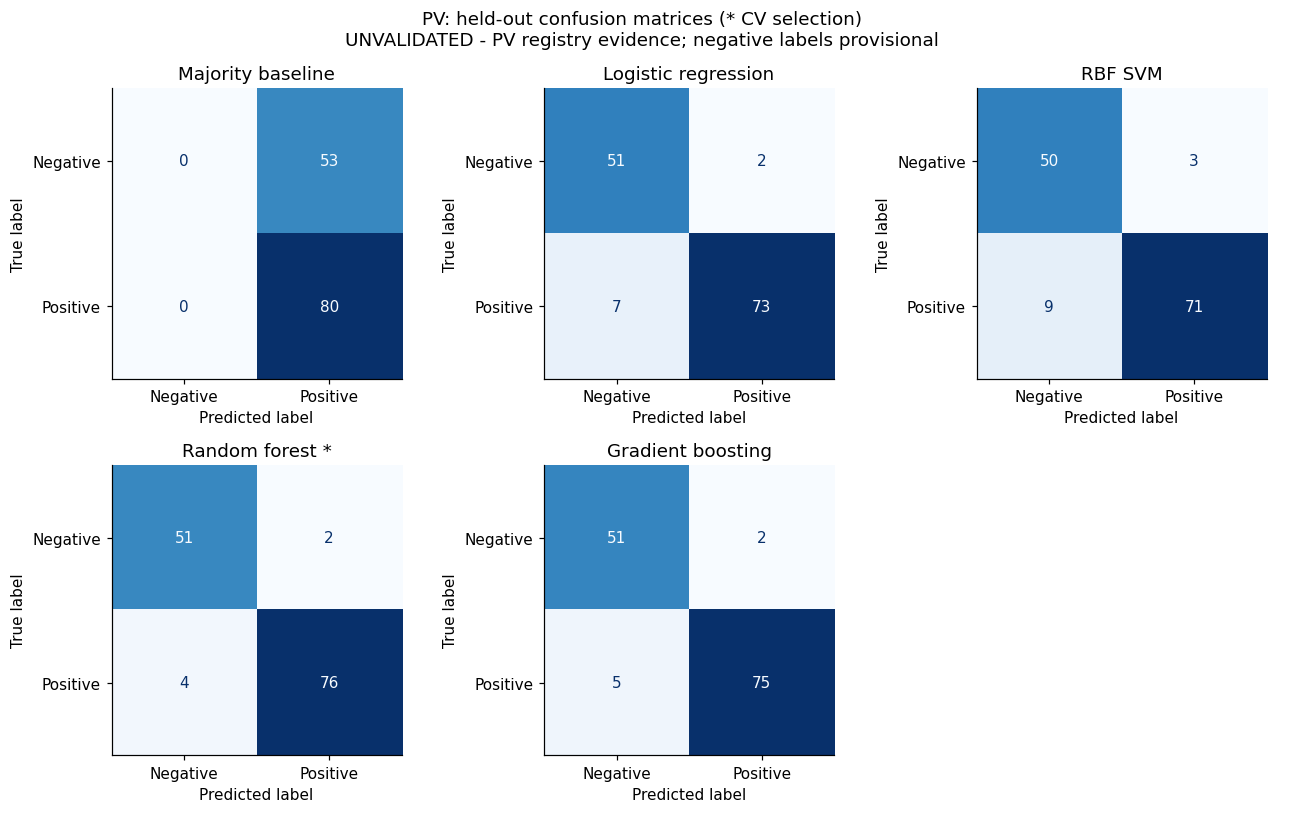

In [67]:
for target, result in results.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
    for model, p in result.predictions.groupby('model', sort=False):
        RocCurveDisplay.from_predictions(p.label, p.score, name=model, ax=axes[0])
        PrecisionRecallDisplay.from_predictions(p.label, p.score, name=model, ax=axes[1])
    prevalence = result.predictions.loc[result.predictions.model.eq(result.selected_name), 'label'].mean()
    axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Chance ranking')
    axes[1].axhline(prevalence, linestyle='--', color='gray', label=f'Prevalence = {prevalence:.3f}')
    axes[0].set(title=f'{target}: held-out ROC')
    axes[1].set(title=f'{target}: held-out precision-recall')
    for ax in axes:
        ax.legend(fontsize=8)
        ax.set_xlim(-.02, 1.02)
        ax.set_ylim(-.02, 1.05)
    fig.suptitle(MODE_NOTES[target])
    fig.tight_layout()
    save_figure(fig, f'09_{target.lower()}_roc_pr')

    fig, axes = plt.subplots(2, 3, figsize=(12, 7.5))
    for ax, model in zip(axes.ravel(), result.test.index):
        p = result.predictions.loc[result.predictions.model.eq(model)]
        ConfusionMatrixDisplay.from_predictions(p.label, p.prediction, labels=[0, 1],
            display_labels=['Negative', 'Positive'], cmap='Blues', colorbar=False, ax=ax)
        ax.set_title(model + (' *' if model == result.selected_name else ''))
        ax.grid(False)
    for ax in axes.ravel()[len(result.test):]:
        ax.axis('off')
    fig.suptitle(f'{target}: held-out confusion matrices (* CV selection)\n{MODE_NOTES[target]}')
    fig.tight_layout()
    save_figure(fig, f'10_{target.lower()}_confusion_matrices')

## 9. Recommended classifiers and interpretation

Recommendations below are generated from the actual training-CV ranking. EV recommends a model for **reproducing its heuristic rule**. With DER data, PV recommends a model for **structure-level prior-PTO evidence versus provisional registry nonmatches**. Neither is fully validated for individual-customer field detection. Holdout scores describe the selected, already frozen model; they do not choose it. A fallback winner is still shown if no learned model beats the baseline, with an explicit statement that no model is supported.

In [68]:
recommendation_rows = []
for target, result in results.items():
    winner = result.selected_name
    cv_row, test_row = result.cv.loc[winner], result.test.loc[winner]
    support = ('Provisional rule-emulation recommendation; ownership unvalidated'
               if result.label_source == 'heuristic_unvalidated' else
               'Provisional structure-level PV recommendation; registry-negative assumption unvalidated'
               if result.label_source.startswith('der_registry') else
               'Candidate supported by held-out user-supplied labels')
    if not result.beats_baseline:
        support = 'No learned classifier beats baseline CV AP; collect better labels/features'
    recommendation_rows.append({
        'target': target, 'recommended_classifier': winner if result.beats_baseline else 'None supported',
        'cv_winner': winner, 'training_cv_AP': cv_row.cv_average_precision,
        'training_cv_AP_sd': cv_row.cv_average_precision_std,
        'test_accuracy': test_row.accuracy,
        'test_accuracy_95pct_low': test_row.accuracy_low,
        'test_accuracy_95pct_high': test_row.accuracy_high,
        'test_balanced_accuracy': test_row.balanced_accuracy,
        'test_precision': test_row.precision, 'test_recall': test_row.recall,
        'test_F1': test_row.f1, 'test_AP': test_row.average_precision,
        'label_source': result.label_source, 'status': support,
    })
    display(Markdown(
        f'**{target}: {winner}** — {support}. '
        f'Training-CV AP **{cv_row.cv_average_precision:.3f} +/- {cv_row.cv_average_precision_std:.3f}** (fold SD). '
        f'Held-out accuracy **{test_row.accuracy:.1%}** '
        f'(95% interval {test_row.accuracy_low:.1%}–{test_row.accuracy_high:.1%}), '
        f'balanced accuracy **{test_row.balanced_accuracy:.1%}**, '
        f'precision **{test_row.precision:.1%}**, recall **{test_row.recall:.1%}**, F1 **{test_row.f1:.3f}**.'))
    ranked = result.cv.drop(index='Majority baseline').sort_values('cv_average_precision', ascending=False)
    if len(ranked) > 1:
        gap = ranked.iloc[0].cv_average_precision - ranked.iloc[1].cv_average_precision
        if gap <= max(ranked.iloc[0].cv_average_precision_std, ranked.iloc[1].cv_average_precision_std):
            display(Markdown('The top two CV AP scores differ by less than one fold standard deviation; '
                             '**the ranking is not decisive**. Prefer a simpler model if operational performance is comparable.'))
    if test_row.recall < .5:
        display(Markdown('**At the default threshold, this model misses more than half of positive labels.** '
                         'Any recall-oriented threshold change needs a new training-only validation exercise and a fresh final holdout.'))

recommendations = pd.DataFrame(recommendation_rows)
display(recommendations.round(3))

**EV: RBF SVM** — Provisional rule-emulation recommendation; ownership unvalidated. Training-CV AP **0.861 +/- 0.062** (fold SD). Held-out accuracy **80.3%** (95% interval 72.8%–86.1%), balanced accuracy **79.3%**, precision **75.9%**, recall **74.5%**, F1 **0.752**.

The top two CV AP scores differ by less than one fold standard deviation; **the ranking is not decisive**. Prefer a simpler model if operational performance is comparable.

**PV: Random forest** — Provisional structure-level PV recommendation; registry-negative assumption unvalidated. Training-CV AP **0.994 +/- 0.004** (fold SD). Held-out accuracy **95.5%** (95% interval 90.5%–97.9%), balanced accuracy **95.6%**, precision **97.4%**, recall **95.0%**, F1 **0.962**.

The top two CV AP scores differ by less than one fold standard deviation; **the ranking is not decisive**. Prefer a simpler model if operational performance is comparable.

,target,recommended_classifier,cv_winner,training_cv_AP,training_cv_AP_sd,test_accuracy,test_accuracy_95pct_low,test_accuracy_95pct_high,test_balanced_accuracy,test_precision,test_recall,test_F1,test_AP,label_source,status
0,EV,RBF SVM,RBF SVM,0.861,0.062,0.803,0.728,0.861,0.793,0.759,0.745,0.752,0.830,heuristic_unvalidated,Provisional rule-emulation recommendation; own...
1,PV,Random forest,Random forest,0.994,0.004,0.955,0.905,0.979,0.956,0.974,0.950,0.962,0.993,der_registry_with_provisional_negatives,Provisional structure-level PV recommendation;...


In [69]:
recommendations

,target,recommended_classifier,cv_winner,training_cv_AP,training_cv_AP_sd,test_accuracy,test_accuracy_95pct_low,test_accuracy_95pct_high,test_balanced_accuracy,test_precision,test_recall,test_F1,test_AP,label_source,status
0,EV,RBF SVM,RBF SVM,0.860816,0.062026,0.802920,0.728444,0.860871,0.793459,0.759259,0.745455,0.752294,0.830078,heuristic_unvalidated,Provisional rule-emulation recommendation; own...
1,PV,Random forest,Random forest,0.994036,0.003993,0.954887,0.905072,0.979163,0.956132,0.974359,0.950000,0.962025,0.992596,der_registry_with_provisional_negatives,Provisional structure-level PV recommendation;...


### What is needed before using these models for EV/PV detection

1. Verify the `STRUCT_NUM` to service-point/meter relationship before interpreting structure-level predictions as individual customer ownership. Independently verify a representative sample of EV rule-positive/negative profiles and PV registry nonmatches. Include PV-plus-storage sites and likely HVAC false positives.
2. Confirm meter units, import/export conventions, local time handling, customer type, and installation dates. Gross consumption may hide PV completely. Obtain weather data to test whether EV predictions track cooling demand.
3. Rerun with confirmed labels and inspect both precision and recall. If false positives are costly, choose a precision target on training-only validation predictions; if missed installations are costly, choose a recall target there.
4. Obtain a complete registry as of the end of the AMI year, then assess a later period or an independent feeder/structure cohort before deployment. Current DER-based PV evaluation ends at the conservative registry cutoff. These splits estimate transfer to other AMI IDs in the same window, not future-year or other-region generalization. Repeated visits to this holdout invalidate its independence.

Hourly sampling obscures short charging sessions; batteries, occupancy, PV self-consumption, and load management can mask or imitate both technologies. These data do not currently justify claims about true ownership accuracy.

## 10. Export reproducible results

CSV outputs include quality exclusions, per-task features, heuristic diagnostics, the DER structure/status/label audit, evaluation labels, train/test IDs, CV-fold membership, fold scores, held-out metrics/predictions, and recommendations. Every prediction includes its label source and score type. Plots are saved as PNG and SVG. No model is refitted on the test set. The saved `results` dictionary contains fitted training-only pipelines for further inspection during this session.

In [70]:
for target, result in results.items():
    prefix = target.lower()
    manifest = pd.DataFrame({'customer_id': list(result.train_ids) + list(result.test_ids),
                             'split': ['train'] * len(result.train_ids) + ['test'] * len(result.test_ids)})
    manifest['label'] = manifest.customer_id.map(labels[f'has_{prefix}'])
    manifest['label_source'] = result.label_source
    manifest.to_csv(RESULTS_DIR / f'{prefix}_split_manifest.csv', index=False)
    result.fold_manifest.to_csv(RESULTS_DIR / f'{prefix}_cv_fold_membership.csv', index=False)
    result.folds.to_csv(RESULTS_DIR / f'{prefix}_cv_fold_scores.csv', index=False)
    result.cv.to_csv(RESULTS_DIR / f'{prefix}_cv_summary.csv')
    result.test.to_csv(RESULTS_DIR / f'{prefix}_test_metrics.csv')
    result.predictions.to_csv(RESULTS_DIR / f'{prefix}_test_predictions.csv', index=False)
recommendations.to_csv(RESULTS_DIR / 'recommendations.csv', index=False)
split_summary.to_csv(RESULTS_DIR / 'split_summary.csv', index=False)
metadata = {
    'dataset': str(DATA_PATH), 'label_sources': LABEL_SOURCES,
    'der_path': str(DER_PATH) if DER_PATH is not None else None,
    'der_audit': registry_audit, 'no_der_record_as_negative': NO_DER_RECORD_AS_NEGATIVE,
    'target_windows': {target: {'start': str(window.index.min()), 'end': str(window.index.max()),
                                'hourly_reads': len(window)} for target, window in target_readings.items()},
    'labels_path': str(LABELS_PATH) if LABELS_PATH is not None else None,
    'timestamp_timezone': TIMESTAMP_TIMEZONE, 'min_coverage': MIN_COVERAGE,
    'random_seed': RANDOM_SEED, 'test_fraction': TEST_SIZE, 'max_cv_folds': CV_FOLDS,
    'selection_metric': 'training CV average precision; balanced accuracy tie-break',
    'units': 'unverified source meter units', 'versions': versions,
    'customer_count': len(quality), 'eligible_count': len(features), 'feature_count': features.shape[1],
    'skipped_tasks': skipped, 'interpretation': MODE_NOTE,
}
(RESULTS_DIR / 'experiment_metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print(f'Results and charts saved to: {RESULTS_DIR}')
print(f'Blank confirmed-label template: {template_path}')

Results and charts saved to: c:\Users\fgonzales\git\itron_pf_platform\runtime\ev_pv_detection\der_registry_provisional
Blank confirmed-label template: c:\Users\fgonzales\git\itron_pf_platform\runtime\ev_pv_detection\customer_labels_template.csv


## Method references

- [scikit-learn: preventing leakage with training-only preprocessing and pipelines](https://scikit-learn.org/stable/common_pitfalls.html)
- [scikit-learn: stratified cross-validation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)
- [scikit-learn: classification metrics, balanced accuracy, ROC, and average precision](https://scikit-learn.org/stable/modules/model_evaluation.html)

These references support the evaluation design. They do not validate the EV/PV screening rules or the dataset's labels.